In [2]:
"""
Autonomous Assistant Agent with MCP Servers
Combines voice activation, MCP server integration, and advanced AI capabilities
"""

from __future__ import annotations
import os
import json
import operator
import httpx
import psutil
import wikipedia
import asyncio
import time
import sys
import speech_recognition as sr
import pyttsx3
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, BaseMessage
from langchain_core.tools import tool, Tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.vectorstores import FAISS

from dotenv import load_dotenv
load_dotenv()

True

 API Keys Importing

In [3]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "YOUR_OPENAI_API_KEY")
NEWSAPI_API_KEY = os.getenv("News_API_KEY", "YOUR_NEWSAPI_KEY")
OPENWEATHER_API_KEY = os.getenv("Weather_API_KEY", "YOUR_OPENWEATHER_KEY")
MCP_API_KEY = os.getenv("MCP_API_KEY")
MODEL_NAME = "gpt-4o-mini"

SandBox for Controlled and Isolated Environment

In [4]:
SANDBOX_DIR = os.path.abspath("./Bitty_sandbox")
RAG_DIR = os.path.abspath("./rag_docs")
INDEX_PATH = os.path.abspath("./rag_index")

os.makedirs(SANDBOX_DIR, exist_ok=True)
os.makedirs(RAG_DIR, exist_ok=True)
os.makedirs(INDEX_PATH, exist_ok=True)



In [5]:
if OPENAI_API_KEY == "YOUR_OPENAI_API_KEY":
    print(" Set OPENAI_API_KEY for LLM + embeddings.")

This Block is for Ayncronised MCP Clients

In [ ]:
class AsyncSystemClient:
    """Async client for the MCP System Server (CPU, processes, shell, files)."""
    
    def __init__(self, base_url="http://127.0.0.1:8000", api_key = "MCP_API_KEY"):
        self.base_url = base_url.rstrip("/")
        self.api_key = api_key
    
    async def get_cpu(self):
        """Get current CPU and memory usage."""
        url = f"{self.base_url}/cpu"
        async with httpx.AsyncClient() as client:
            response = await client.get(url, params={"api_key": self.api_key})
            return response.json()
    
    async def list_processes(self):
        """Get list of running processes."""
        url = f"{self.base_url}/ps"
        async with httpx.AsyncClient() as client:
            response = await client.get(url, params={"api_key": self.api_key})
            return response.json()
    
    async def open_app(self, path: str):
        """Open an application by path."""
        url = f"{self.base_url}/open_app"
        async with httpx.AsyncClient() as client:
            response = await client.post(url, params={"path": path, "api_key": self.api_key})
            return response.json()
    
    async def run_shell(self, cmd: str, confirm: bool = True, timeout: int = 10):
        """Run a shell command."""
        url = f"{self.base_url}/shell"
        payload = {"cmd": cmd, "confirm": confirm, "timeout": timeout}
        async with httpx.AsyncClient() as client:
            response = await client.post(url, json=payload, params={"api_key": self.api_key})
            return response.json()
    
    async def read_file(self, path: str, max_bytes: int = 5 * 1024 * 1024):
        """Read a file."""
        url = f"{self.base_url}/read_file"
        async with httpx.AsyncClient() as client:
            response = await client.get(url, params={"path": path, "max_bytes": max_bytes, "api_key": self.api_key})
            return response.json()
    
    async def write_file(self, path: str, content: str):
        """Write content to a file."""
        url = f"{self.base_url}/write_file"
        async with httpx.AsyncClient() as client:
            response = await client.post(url, params={"path": path, "content": content, "api_key": self.api_key})
            return response.json()
    
    async def append_file(self, path: str, content: str):
        """Append content to a file."""
        url = f"{self.base_url}/append_file"
        async with httpx.AsyncClient() as client:
            response = await client.post(url, params={"path": path, "content": content, "api_key": self.api_key})
            return response.json()
    
    async def file_op(self, src: str, dst: str = None, confirm: bool = True):
        """Perform file operations."""
        url = f"{self.base_url}/file_op"
        payload = {"src": src, "dst": dst, "confirm": confirm}
        async with httpx.AsyncClient() as client:
            response = await client.post(url, json=payload, params={"api_key": self.api_key})
            return response.json()

class AsyncProductivityClient:
    """Async client for the MCP Productivity Server (Gmail + Calendar + Summarization)."""
    
    def __init__(self, base_url = "http://127.0.0.1:8020"):
        self.base_url = base_url.rstrip("/")
    
    async def send_email(self, to: str, subject: str, message: str):
        """Send an email using Gmail API."""
        url = f"{self.base_url}/email/send"
        payload = {"to": to, "subject": subject, "message": message}
        async with httpx.AsyncClient() as client:
            response = await client.post(url, json=payload)
            return response.json()
    
    async def read_emails(self, max_results: int = 5):
        """Fetch last N unread emails."""
        url = f"{self.base_url}/email/read"
        async with httpx.AsyncClient() as client:
            response = await client.get(url, params={"max_results": max_results})
            return response.json()
    
    async def get_calendar_events(self, max_results: int = 5):
        """Fetch upcoming calendar events."""
        url = f"{self.base_url}/calendar/events"
        async with httpx.AsyncClient() as client:
            response = await client.get(url, params={"max_results": max_results})
            return response.json()
    
    async def summarize_and_send(self, raw_text: str, to: str, subject: str):
        """Summarize raw text into a professional email and send."""
        url = f"{self.base_url}/email/summarize_and_send"
        payload = {"raw_text": raw_text, "to": to, "subject": subject}
        async with httpx.AsyncClient() as client:
            response = await client.post(url, json=payload)
            return response.json()

class AsyncWebClient:
    """Async client for the MCP Web Search Server (DuckDuckGo)."""
    
    def __init__(self, base_url="http://127.0.0.1:8010"):
        self.base_url = base_url.rstrip("/")
    
    async def search_web(self, query: str, max_results: int = 5):
        """Perform a DuckDuckGo web search."""
        url = f"{self.base_url}/search"
        async with httpx.AsyncClient() as client:
            response = await client.get(url, params={"query": query, "max_results": max_results})
            return response.json()

Objects of async MCP clients Classes

In [ ]:
sysc = AsyncSystemClient()
prodc = AsyncProductivityClient()
webc = AsyncWebClient()

Tools Defining

In [7]:
async def cpu_monitor_tool(_: str = "") -> str:
    """Report CPU and memory utilization in percent."""
    cpu = await asyncio.to_thread(psutil.cpu_percent, interval=0.7)
    mem = await asyncio.to_thread(lambda: psutil.virtual_memory().percent)
    return f"CPU usage: {cpu:.1f}%, Memory usage: {mem:.1f}%."

async def safe_delete_tool(rel_path: str) -> str:
    """Delete a file under sandbox. Input is relative path under jarvis_sandbox."""
    if not rel_path:
        return "Provide a relative path under sandbox (e.g., notes/todo.txt)."
    
    abs_path = os.path.abspath(os.path.join(SANDBOX_DIR, rel_path))
    
    if not abs_path.startswith(SANDBOX_DIR):
        return "Refused: path escapes sandbox."
    
    if not os.path.exists(abs_path):
        return f"File not found: {rel_path}"
    
    try:
        await asyncio.to_thread(os.remove, abs_path)
        return f"Deleted: {rel_path}"
    except Exception as e:
        return f"Failed to delete {rel_path}: {e}"

async def news_tool_tool(country_code: str = "us") -> str:
    """Top headlines via NewsAPI for a country code."""
    if not NEWSAPI_API_KEY or NEWSAPI_API_KEY == "YOUR_NEWSAPI_KEY":
        return "NewsAPI key missing."
    
    url = "https://newsapi.org/v2/top-headlines"
    params = {"country": country_code, "apiKey": NEWSAPI_API_KEY, "pageSize": 5}
    async with httpx.AsyncClient() as client:
        response = await client.get(url, params=params, timeout=10.0)
        data = response.json()
    
    if data.get("status") != "ok":
        return f"NewsAPI error: {data}"
    titles = [a["title"] for a in data.get("articles", [])]
    return "Top headlines:\n- " + "\n- ".join(titles) if titles else "No headlines."

async def weather_tool_tool(city: str = "Karachi") -> str:
    """Current weather for a city using OpenWeather (metric)."""
    if not OPENWEATHER_API_KEY or OPENWEATHER_API_KEY == "YOUR_OPENWEATHER_KEY":
        return "OpenWeather key missing."
    
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"q": city, "appid": OPENWEATHER_API_KEY, "units": "metric"}
    async with httpx.AsyncClient() as client:
        response = await client.get(url, params=params, timeout=10.0)
        data = response.json()
    
    if "main" not in data:
        return f"Weather error: {data.get('message', data)}"
    temp = data["main"]["temp"]
    desc = data["weather"][0]["description"]
    return f"Weather in {city}: {temp}°C, {desc}."

async def wiki_tool_tool(query: str) -> str:
    """Search Wikipedia for information."""
    try:
        # Use asyncio.to_thread for synchronous wikipedia operations
        search_results = await asyncio.to_thread(wikipedia.search, query, results=1)
        if not search_results:
            return f"No Wikipedia articles found for '{query}'"
        
        page = await asyncio.to_thread(wikipedia.page, search_results[0])
        summary = await asyncio.to_thread(wikipedia.summary, search_results[0], sentences=3)
        return f"Wikipedia result for '{query}':\n{summary}\n\nFull article: {page.url}"
    except wikipedia.exceptions.DisambiguationError as e:
        return f"Multiple matches found for '{query}'. Please be more specific."
    except wikipedia.exceptions.PageError:
        return f"No Wikipedia page found for '{query}'"
    except Exception as e:
        return f"Wikipedia search failed: {e}"

This Block has RAG Tools

In [8]:
async def build_rag_index() -> str:
    """Build RAG index from documents in rag_docs directory."""
    docs = []
    
    for name in os.listdir(RAG_DIR):
        path = os.path.join(RAG_DIR, name)
        
        if os.path.isfile(path) and any(name.lower().endswith(ext) for ext in [".txt", ".md"]):
            async with asyncio.Lock():
                with open(path, "r", encoding="utf-8", errors="ignore") as f:
                    text = f.read()
            chunks = [text[i:i+1500] for i in range(0, len(text), 1500)]
            for idx, chunk in enumerate(chunks):
                docs.append({"page_content": chunk, "metadata": {"source": name, "chunk": idx}})
    
    if not docs:
        return "No text files found in rag_docs."
    
    embeddings = OpenAIEmbeddings()
    vs = await asyncio.to_thread(
        FAISS.from_texts,
        [d["page_content"] for d in docs],
        embedding=embeddings,
        metadatas=[d["metadata"] for d in docs]
    )
    await asyncio.to_thread(vs.save_local, INDEX_PATH)
    return f"RAG index built with {len(docs)} chunks."

async def load_vectorstore():
    """Load the vector store for RAG search."""
    embeddings = OpenAIEmbeddings()
    return await asyncio.to_thread(
        FAISS.load_local,
        INDEX_PATH,
        embeddings,
        allow_dangerous_deserialization=True
    )

async def rag_search_tool(query: str) -> str:
    """Semantic search over local docs."""
    try:
        vs = await load_vectorstore()
        docs = await asyncio.to_thread(vs.similarity_search, query, k=3)
        lines = []
        for d in docs:
            meta = d.metadata or {}
            src = meta.get("source", "?")
            ch = meta.get("chunk", "?")
            lines.append(f"- ({src}#chunk{ch}) {d.page_content[:300]}...")
        
        return "RAG results:\n" + "\n".join(lines) if lines else "No similar chunks found."
    except Exception as e:
        return f"RAG search failed: {e}"

This Block has Persistant Memory & Tools

In [9]:
MEMORY_FILE = os.path.join(SANDBOX_DIR, "memory.json")

async def load_memory() -> dict:
    """Load persistent memory from file."""
    if os.path.exists(MEMORY_FILE):
        try:
            async with asyncio.Lock():
                with open(MEMORY_FILE, "r", encoding="utf-8") as f:
                    return json.load(f)
        except:
            return {}
    return {}

async def save_memory(mem: dict) -> None:
    """Save persistent memory to file."""
    async with asyncio.Lock():
        with open(MEMORY_FILE, "w", encoding="utf-8") as f:
            json.dump(mem, f, ensure_ascii=False, indent=2)

async def remember_tool(kv: str) -> str:
    """Store key=value fact. Input: key::value"""
    if "::" not in kv:
        return "Use key::value format."
    key, value = [x.strip() for x in kv.split("::", 1)]
    mem = await load_memory()
    mem[key] = value
    await save_memory(mem)
    return f"Remembered {key}."

async def recall_tool(key: str) -> str:
    """Retrieve fact by key"""
    mem = await load_memory()
    return f"{key} = {mem[key]}" if key in mem else f"No value found for {key}."

state that passes from node to node

In [10]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    tool_calls: Annotated[list[str], operator.add]
    memory: dict
    scratchpad: str

This Block is for Routre Decision to Call Concerning Tool

In [ ]:
class RouteDecision(BaseModel):
    action: Literal[
        "answer", "tool:cpu_monitor", "tool:safe_delete", "tool:news_tool", 
        "tool:weather_tool", "tool:wiki_tool", "tool:rag_search", "tool:remember", 
        "tool:recall", "mcp:system", "mcp:productivity", "mcp:web", "confirm_delete"
    ]
    argument: str = Field("", description="Argument for the chosen action/tool")

llm = ChatOpenAI(
    model=MODEL_NAME,
    temperature=0.6,
)

structured_llm = llm.with_structured_output(RouteDecision)

SYSTEM_ROUTER = SystemMessage(content=(
    "You are a Bitty autonomous assistant router. Available tools:\n"
    " cpu_monitor: System monitoring\n"
    " safe_delete: File deletion (requires confirmation)\n"
    " news_tool: News headlines\n"
    " weather_tool: Weather information\n"
    " wiki_tool: Wikipedia search\n"
    " rag_search: Local document search\n"
    " remember/recall: Memory operations\n"
    " mcp:system: System operations (CPU, processes, files, shell)\n"
    " mcp:productivity: Email and calendar operations\n"
    " mcp:web: Web search operations\n"
    "For file deletions: NEVER call safe_delete directly. Use confirm_delete instead.\n"
    "Route to appropriate MCP server for system, productivity, or web operations."
))

async def llm_router(state: AgentState) -> AgentState:
    """Route user requests to appropriate tools or MCP servers."""
    convo = [SYSTEM_ROUTER] + state["messages"]
    decision: RouteDecision = await structured_llm.ainvoke(convo)
    note = f"ROUTER -> {decision.action} | arg={decision.argument}"
    
    return {
        "messages": [AIMessage(content=note)],
        "tool_calls": [decision.action],
        "memory": state.get("memory", {}),
        "scratchpad": state.get("scratchpad", "")
    }



Human in the Loop

In [ ]:
async def confirmation_node(state: AgentState) -> AgentState:
    """Handle file deletion confirmations."""
    last_ai = state["messages"][-1].content if state.get("messages") else ""
    arg = last_ai.split("| arg=", 1)[-1] if "| arg=" in last_ai else ""
    mem = await load_memory()
    mem["pending_delete"] = arg
    await save_memory(mem)
    prompt = f"Are you sure you want to delete '{arg}' from sandbox? Reply YES or NO."
    
    return {
        "messages": [AIMessage(content=prompt)],
        "tool_calls": [],
        "memory": mem,
        "scratchpad": state.get("scratchpad", "")
    }

This Block Dispatches Concerning Tool

In [12]:
TOOLS_BY_NAME = {
    "cpu_monitor": cpu_monitor_tool,
    "safe_delete": safe_delete_tool,
    "news_tool": news_tool_tool,
    "weather_tool": weather_tool_tool,
    "wiki_tool": wiki_tool_tool,
    "rag_search": rag_search_tool,
    "remember": remember_tool,
    "recall": recall_tool
}

async def tool_dispatcher(state: AgentState) -> AgentState:
    """Dispatch tool calls to appropriate async functions."""
    if not state.get("tool_calls"):
        return {
            "messages": [],
            "tool_calls": [],
            "memory": state.get("memory", {}),
            "scratchpad": state.get("scratchpad", "")
        }
    
    decision = state["tool_calls"][-1]
    
    if not decision.startswith("tool:"):
        return {
            "messages": [],
            "tool_calls": [],
            "memory": state.get("memory", {}),
            "scratchpad": state.get("scratchpad", "")
        }
    
    tool_name = decision.split("tool:", 1)[-1]
    tool_fn = TOOLS_BY_NAME.get(tool_name)
    
    last_ai = state["messages"][-1].content if state.get("messages") else ""
    argument = last_ai.split("| arg=", 1)[-1] if "| arg=" in last_ai else ""
    
    try:
        result = await tool_fn(argument)
    except Exception as e:
        result = f"Tool `{tool_name}` failed: {e}"
    
    return {
        "messages": [AIMessage(content=f"[{tool_name}]: {result}")],
        "tool_calls": [],
        "memory": state.get("memory", {}),
        "scratchpad": state.get("scratchpad", "")
    }

This Block Dispatches Concerning MCP Server

In [ ]:
async def mcp_dispatcher(state: AgentState) -> AgentState:
    """Dispatch MCP server calls."""
    if not state.get("tool_calls"):
        return {
            "messages": [],
            "tool_calls": [],
            "memory": state.get("memory", {}),
            "scratchpad": state.get("scratchpad", "")
        }
    
    decision = state["tool_calls"][-1]
    
    if not decision.startswith("mcp:"):
        return {
            "messages": [],
            "tool_calls": [],
            "memory": state.get("memory", {}),
            "scratchpad": state.get("scratchpad", "")
        }
    
    mcp_type = decision.split("mcp:", 1)[-1]
    last_ai = state["messages"][-1].content if state.get("messages") else ""
    argument = last_ai.split("| arg=", 1)[-1] if "| arg=" in last_ai else ""
    
    print(f"DEBUG: MCP call - {mcp_type}")
    print(f"DEBUG: Argument - {argument}")
    
    try:
        if mcp_type == "system":
            if "cpu" in argument.lower() or "memory" in argument.lower():
                result = await sysc.get_cpu()
            elif "process" in argument.lower():
                result = await sysc.list_processes()
            elif "open" in argument.lower():
                result = await sysc.open_app("notepad.exe")
            elif "file" in argument.lower() or "read" in argument.lower():
                result = await sysc.read_file("test.txt", max_bytes=1024)
            else:
                result = {"note": "System MCP - specify operation"}
        
        elif mcp_type == "productivity":
            try:
                args = json.loads(argument) if argument else {}
            except Exception:
                return {"error": f"Invalid JSON argument: {argument}"}

            op = args.get("operation")

                #  email Send=
            if op == "send_email" or ("to" in args and ("message" in args or "body" in args)):
                result = await prodc.send_email(
                to=args.get("to"),
                subject=args.get("subject", ""),
                message=args.get("message", args.get("body", ""))
                )

                    
            elif op == "read_email":
                result = await prodc.read_emails(max_results=args.get("max_results", 5))

                
            elif op in ["get_calendar", "calendar"]:
                result = await prodc.get_calendar_events(max_results=args.get("max_results", 5))

            else:
                result = {"error": f"Unrecognized productivity operation: {argument}"}

        
        elif mcp_type == "web":
            if "search" in argument.lower():
                query = argument.replace("search", "").strip()
                result = await webc.search_web(query)
            else:
                result = {"note": "Web MCP - specify search query"}
        
        else:
            result = {"error": f"Unknown MCP type: {mcp_type}"}
    
    except httpx.ConnectError:
        result = f"MCP `{mcp_type}` server not running. Start with: python start_servers.py"
    except httpx.TimeoutException:
        result = f"MCP `{mcp_type}` request timed out"
    except Exception as e:
        result = f"MCP `{mcp_type}` failed: {e}"
    
    print(f"DEBUG: Response - {result}")
    
    return {
        "messages": [AIMessage(content=f"[MCP:{mcp_type}]: {result}")],
        "tool_calls": [],
        "memory": state.get("memory", {}),
        "scratchpad": state.get("scratchpad", "")
    }


This Block Passes the final output

In [14]:
async def final_answer(state: AgentState) -> AgentState:
    """Generate final response to user."""
    last_assistant = None
    
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage):
            last_assistant = msg
            break
    
    content = last_assistant.content if last_assistant else "Done."
    
    return {
        "messages": [AIMessage(content=content)],
        "tool_calls": [],
        "memory": state.get("memory", {}),
        "scratchpad": state.get("scratchpad", "")
    }

Building Graph

In [15]:
def route_decision(state: AgentState) -> Literal["to_tool", "to_mcp", "to_answer", "to_confirm"]:
    """Route to appropriate node based on tool calls."""
    if not state.get("tool_calls"):
        return "to_answer"
    
    last = state["tool_calls"][-1]
    
    if last == "confirm_delete":
        return "to_confirm"
    
    if last.startswith("tool:"):
        return "to_tool"
    
    if last.startswith("mcp:"):
        return "to_mcp"
    
    return "to_answer"

graph = StateGraph(AgentState)

graph.add_node("llm_router", llm_router)
graph.add_node("confirmation", confirmation_node)
graph.add_node("tool_dispatcher", tool_dispatcher)
graph.add_node("mcp_dispatcher", mcp_dispatcher)
graph.add_node("final_answer", final_answer)

graph.set_entry_point("llm_router")
graph.add_conditional_edges(
    "llm_router",
    route_decision,
    {
        "to_tool": "tool_dispatcher",
        "to_mcp": "mcp_dispatcher",
        "to_answer": "final_answer",
        "to_confirm": "confirmation"
    }
)
graph.add_edge("confirmation", "final_answer")
graph.add_edge("tool_dispatcher", "llm_router")
graph.add_edge("mcp_dispatcher", "llm_router")
graph.add_edge("final_answer", END)

app = graph.compile(checkpointer=MemorySaver())

print(" Async Bitty Autonomous Assistant Graph compiled successfully!")

 Async Bitty Autonomous Assistant Graph compiled successfully!


This Block shows the graph visually

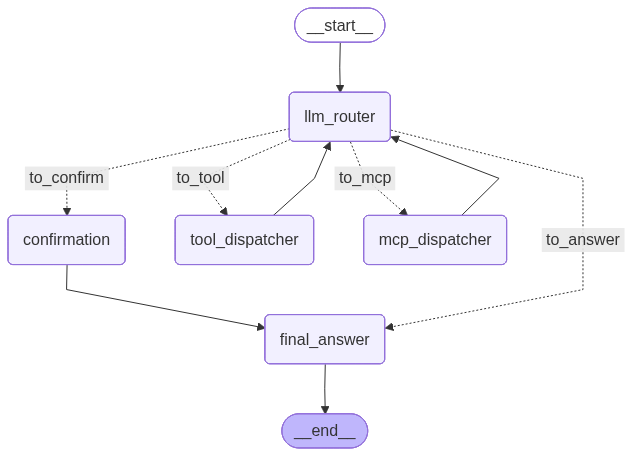

In [ ]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
    
except ImportError:
    print("Graph visualization skipped (IPython not available in this environment)")
    # Alternative: save graph as image file
    try:
        import graphviz
        app.get_graph().draw_mermaid_png("Bitty_graph.png")
        print("Graph saved as 'Bitty_graph.png'")
    except:
        print("Graph visualization not available")

This Block is the Main Runner

In [ ]:
async def run_bitty(user_text: str, thread_id: str = "demo") -> str:
    """Run the autonomous assistant with user input."""
    mem = await load_memory()
    state = {
        "messages": [HumanMessage(content=user_text)],
        "tool_calls": [],
        "memory": mem,
        "scratchpad": ""
    }
    
    out = await app.ainvoke(
        state,
        config={"recursion_limit": 10000, "configurable": {"thread_id": thread_id}}
    )
    
    await save_memory(out.get("memory", mem))
    
    final = None
    for m in reversed(out["messages"]):
        if isinstance(m, AIMessage):
            final = m
            break
    
    # Clean up response
    word_to_find = "arg"
    if word_to_find in final.content:
        index = final.content.find(word_to_find)
        return final.content[index + len(word_to_find) + 1:].strip()
    else:
        return final.content if final else "No response generated"

This Block is to Manage Voice Functionality

In [17]:
def speak(text):
    """Text-to-speech using pyttsx3."""
    engine = pyttsx3.init()
    engine.say(text)
    engine.runAndWait()
    engine.stop()

def listen_command(prompt="Listening...", timeout=10, phrase_time_limit=20):
    """Listen for voice command and return recognized text."""
    recognizer = sr.Recognizer()
    mic = sr.Microphone()
    
    with mic as source:
        recognizer.adjust_for_ambient_noise(source)
        print(prompt)
        
        try:
            audio = recognizer.listen(source, timeout=timeout, phrase_time_limit=phrase_time_limit)
            text = recognizer.recognize_google(audio)
            print("Heard:", text)
            return text.lower()
        except sr.UnknownValueError:
            print("Could not understand audio")
            return ""
        except sr.RequestError:
            print("Error: check your internet connection.")
            return ""
        except sr.WaitTimeoutError:
            print("Error: Wait Time Out Error Occurred")
            return ""

async def listen_for_wake_word(wake_word="wake up", active_timeout=15):
    """Wake word detection with active listening mode."""
    active_mode = False
    last_command_time = 0
    
    while True:
        if not active_mode:
            # Waiting for wake word
            speak("Bitty Autonomous Assistant started. Say 'wake up' to activate.")
            text = await asyncio.to_thread(listen_command, f"Waiting for wake word: '{wake_word}'...")
            if wake_word in text:
                speak("Yes, I'm listening?")
                active_mode = True
                last_command_time = time.time()
        else:
            # Already awake, listen for commands
            while True:
                command = await asyncio.to_thread(listen_command, "Listening for your command...")
                
                if not command:
                    # No command heard: check if timeout expired
                    if time.time() - last_command_time > active_timeout:
                        print("Going back to sleep, say 'wake up' to activate again")
                        speak("Going back to sleep, say 'wake up' to activate again.")
                        active_mode = False
                        break
                    continue
                
                last_command_time = time.time()
                print(f"Processing command: {command}")
                
                # Process command through the assistant
                result = await run_bitty(command)
                print(f"Response: {result}")
                speak(result)
                
                # Check for exit command
                if result.lower() == "exit" or "goodbye" in result.lower():
                    print("Exiting as requested")
                    speak("Goodbye!")
                    sys.exit("Exiting as User asked")

This Block is Main

In [ ]:
async def async_main():
    """Async main function for testing without voice."""
    print("Bitty Async Autonomous Assistant Ready!")
    print("Type 'exit' to quit")
    
    while True:
        try:
            user_input = input("You: ")
            if user_input.lower() in ("exit", "quit", "goodbye"):
                print("Goodbye!")
                break
            
            response = await run_bitty(user_input)
            print(f"Assistant: {response}")
            
        except KeyboardInterrupt:
            print("\nGoodbye!")
            break
        except Exception as e:
            print(f"Error: {e}")

This __name__ thing lets you run code only if its executed in main file

In [ ]:
import re
import signal
import logging
from typing import Optional

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('jarvis.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

def signal_handler(signum, frame):
    """Handle shutdown signals gracefully."""
    print("\n Shutting down gracefully...")
    # Cleanup code here
    sys.exit(0)

def validate_config():
    """Validate that all required configuration is present."""
    issues = []
    
    if OPENAI_API_KEY == "YOUR_OPENAI_API_KEY":
        issues.append(" OPENAI_API_KEY not set in .env file")
    
    if NEWSAPI_API_KEY == "YOUR_NEWSAPI_KEY":
        issues.append(" News_API_KEY not set in .env file")
    
    if OPENWEATHER_API_KEY == "YOUR_OPENWEATHER_KEY":
        issues.append(" Weather_API_KEY not set in .env file")
    
    if not os.path.exists("credentials.json"):
        issues.append(" credentials.json not found (required for email/calendar)")
    
    if issues:
        print(" Configuration Issues Found:")
        for issue in issues:
            print(f"   {issue}")
        print("\n Fix these issues for full functionality.")
    else:
        print(" All configuration validated successfully!")

async def check_mcp_servers():
    """Check if all MCP servers are running."""
    servers = [
        ("System", "http://127.0.0.1:8000/cpu?api_key=test-key"),
        ("Productivity", "http://127.0.0.1:8020/health"),
        ("Web", "http://127.0.0.1:8010/search?query=test")
    ]
    
    results = {}
    for name, url in servers:
        try:
            async with httpx.AsyncClient(timeout=5.0) as client:
                response = await client.get(url)
                results[name] = f" Running (Status: {response.status_code})"
        except Exception as e:
            results[name] = f" Not running: {e}"
    
    return results

async def retry_mcp_call(func, max_retries=3, delay=1):
    """Retry MCP calls with exponential backoff."""
    for attempt in range(max_retries):
        try:
            return await func()
        except httpx.ConnectError as e:
            if attempt == max_retries - 1:
                raise e
            await asyncio.sleep(delay * (2 ** attempt))
            logger.warning(f"MCP call failed, retrying... (attempt {attempt + 1})")

def create_env_template():
    """Create a template .env file if it doesn't exist."""
    if not os.path.exists(".env"):
        env_content = """#Bitty AI Voice Assistant Configuration """
    
        with open(".env", "w") as f:
            f.write(env_content)
        print(" Created .env template file. Please fill in your API keys.")
        return True
    return False

async def startup():
    validate_config()
    create_env_template()
    # Create necessary directories and files
    os.makedirs(os.path.join(SANDBOX_DIR, "notes"), exist_ok=True)
    async with asyncio.Lock():
        with open(os.path.join(SANDBOX_DIR, "notes", "todo.txt"), "w") as f:
            f.write("Async Autonomous Assistant initialized")
    
    # Check MCP servers
    print("🔍 Checking MCP servers...")
    server_status = await check_mcp_servers()
    for server, status in server_status.items():
        print(f"   {server}: {status}")
    
    # Build RAG index if documents exist
    try:
        await build_rag_index()
        print(" RAG index built successfully")
    except Exception as e:
        print(f" RAG index build failed: {e}")

if __name__ == "__main__":
    signal.signal(signal.SIGINT, signal_handler)
    signal.signal(signal.SIGTERM, signal_handler)
    
    # Choose interface mode
    import sys
    
    if len(sys.argv) > 1 and sys.argv[1] == "--voice":
        print(" Starting voice-activated mode...")
        asyncio.run(startup())
        asyncio.run(listen_for_wake_word("wake up"))

    else:
        print(" Starting text interface mode...")
        asyncio.run(startup())
        asyncio.run(async_main())

⌨️ Starting text interface mode...


RuntimeError: asyncio.run() cannot be called from a running event loop